# Bài 5 [Kaggle] - Home Credit Default Risk

Notebook sử dụng hai bảng chính `application_train.csv` và `application_test.csv` để:

1. Phân khúc khách hàng bằng **K-means của scikit-learn**.
2. Chọn số cluster bằng elbow method.
3. Mô tả đặc điểm kinh doanh và tỷ lệ vỡ nợ thật của từng cluster.
4. So sánh Logistic Regression có và không có feature `CLUSTER`.
5. Tạo `submission.csv` để nộp lên Kaggle.

> Trên Colab, hãy chạy cell bên dưới và chọn **cùng lúc hai file** `application_train.csv`, `application_test.csv`.

## 1. Upload và đọc dữ liệu

In [1]:
from pathlib import Path

try:
    from google.colab import files

    print("Chọn application_train.csv và application_test.csv")
    uploaded = files.upload()
    TRAIN_PATH = next(name for name in uploaded if Path(name).name == "application_train.csv")
    TEST_PATH = next(name for name in uploaded if Path(name).name == "application_test.csv")
    del uploaded  # Giải phóng bản sao dữ liệu đang giữ trong RAM
except ImportError:
    # Khi chạy notebook trong thư mục project trên máy cá nhân
    TRAIN_PATH = "application_train.csv"
    TEST_PATH = "application_test.csv"

print("Train file:", TRAIN_PATH)
print("Test file :", TEST_PATH)

Chọn application_train.csv và application_test.csv


Saving application_test.csv to application_test.csv
Saving application_train.csv to application_train.csv
Train file: application_train.csv
Test file : application_test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())

Train shape: (307511, 122)
Test shape : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Chọn và tạo feature dễ giải thích

K-means dùng các thông tin nhân khẩu học/tài chính chính: thu nhập, khoản vay, tiền trả hàng năm, tuổi, số năm làm việc, số thành viên gia đình và loại hợp đồng.

`DAYS_BIRTH` và `DAYS_EMPLOYED` đang được lưu dưới dạng số ngày âm. Ta đổi chúng thành số năm dương. Giá trị `365243` ở `DAYS_EMPLOYED` là mã đặc biệt của Home Credit cho trường hợp không có thông tin việc làm, nên được đổi thành giá trị thiếu để imputer xử lý. Ba biến tiền có phân phối lệch mạnh, vì vậy dùng `log1p` trước khi phân cụm để vài giá trị rất lớn không chi phối khoảng cách.

In [3]:
def create_features(df):
    data = df.copy()
    data["AGE_YEARS"] = -data["DAYS_BIRTH"] / 365.25
    data["EMPLOYED_YEARS"] = -data["DAYS_EMPLOYED"] / 365.25
    data.loc[data["DAYS_EMPLOYED"] == 365243, "EMPLOYED_YEARS"] = np.nan
    data["LOG_INCOME"] = np.log1p(data["AMT_INCOME_TOTAL"])
    data["LOG_CREDIT"] = np.log1p(data["AMT_CREDIT"])
    data["LOG_ANNUITY"] = np.log1p(data["AMT_ANNUITY"])
    return data

train_data = create_features(train_df)
test_data = create_features(test_df)

In [4]:
CLUSTER_NUMERIC_FEATURES = [
    "LOG_INCOME",
    "LOG_CREDIT",
    "LOG_ANNUITY",
    "AGE_YEARS",
    "EMPLOYED_YEARS",
    "CNT_FAM_MEMBERS",
]
CLUSTER_CATEGORICAL_FEATURES = ["NAME_CONTRACT_TYPE"]
CLUSTER_FEATURES = CLUSTER_NUMERIC_FEATURES + CLUSTER_CATEGORICAL_FEATURES

print(train_data[CLUSTER_FEATURES].dtypes)
print("\nSố giá trị thiếu:")
display(train_data[CLUSTER_FEATURES].isna().sum().to_frame("missing"))
display(train_data[CLUSTER_NUMERIC_FEATURES].describe().round(2))

LOG_INCOME            float64
LOG_CREDIT            float64
LOG_ANNUITY           float64
AGE_YEARS             float64
EMPLOYED_YEARS        float64
CNT_FAM_MEMBERS       float64
NAME_CONTRACT_TYPE     object
dtype: object

Số giá trị thiếu:


,missing
LOG_INCOME,0
LOG_CREDIT,0
LOG_ANNUITY,12
AGE_YEARS,0
EMPLOYED_YEARS,55374
CNT_FAM_MEMBERS,2
NAME_CONTRACT_TYPE,0


,LOG_INCOME,LOG_CREDIT,LOG_ANNUITY,AGE_YEARS,EMPLOYED_YEARS,CNT_FAM_MEMBERS
count,307511.00,307511.00,307499.00,307511.00,252137.00,307509.00
mean,11.91,13.07,10.07,43.91,6.53,2.15
std,0.49,0.72,0.55,11.95,6.40,0.91
min,10.15,10.71,7.39,20.50,0.00,1.00
25%,11.63,12.51,9.71,33.98,2.10,2.00
50%,11.90,13.15,10.12,43.12,4.51,2.00
75%,12.22,13.60,10.45,53.89,8.69,3.00
max,18.58,15.21,12.46,69.07,49.04,20.00


Các feature số được điền thiếu bằng median và chuẩn hóa vì K-means dựa trên khoảng cách. Feature loại hợp đồng được điền bằng mode rồi one-hot encoding. Mọi bước được fit trên train và chỉ transform test.

In [5]:
def make_cluster_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, CLUSTER_NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CLUSTER_CATEGORICAL_FEATURES),
    ])

cluster_preprocessor = make_cluster_preprocessor()
X_cluster = cluster_preprocessor.fit_transform(train_data[CLUSTER_FEATURES])

print("Shape sau preprocessing:", X_cluster.shape)
print("Có NaN:", np.isnan(X_cluster).any())
print("Có inf:", np.isinf(X_cluster).any())

Shape sau preprocessing: (307511, 8)
Có NaN: False
Có inf: False


## 3. Elbow method chọn số cluster

Ta thử từ 2 đến 8 cluster và vẽ inertia. Để cell chạy nhanh trên Colab, elbow method dùng mẫu ngẫu nhiên tối đa 50.000 khách hàng. Mẫu này chỉ dùng để chọn `k`; mô hình K-means cuối cùng vẫn fit trên toàn bộ train.

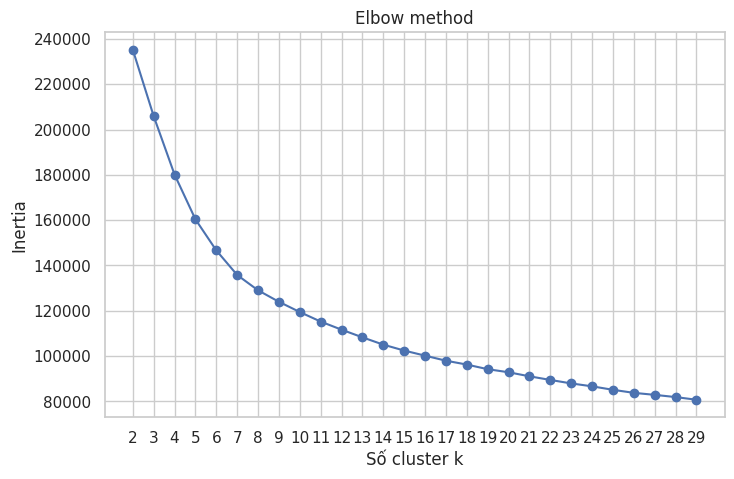

In [9]:
sample_size = min(50_000, len(X_cluster))
sample_indices = np.random.choice(len(X_cluster), size=sample_size, replace=False)
X_elbow = X_cluster[sample_indices]

k_values = range(2, 30)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    model.fit(X_elbow)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Số cluster k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.xticks(list(k_values))
plt.show()

Quan sát điểm mà đường inertia bắt đầu giảm chậm rõ rệt rồi đặt `N_CLUSTERS` bên dưới. Với dữ liệu này, **4** là một lựa chọn khởi đầu dễ diễn giải; kết quả biểu đồ khi chạy notebook là căn cứ cuối cùng.

In [13]:
N_CLUSTERS = 8

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
)
train_data["CLUSTER"] = kmeans.fit_predict(X_cluster)

train_data["CLUSTER"].value_counts().sort_index()

,count
CLUSTER,
0,59008
1,36384
2,28570
3,40512
4,42769
5,21810
6,45400
7,33058


## 4. Trực quan hóa và diễn giải cluster

PCA nén không gian đã chuẩn hóa xuống hai chiều để vẽ. PCA chỉ phục vụ trực quan hóa, không thay đổi nhãn cluster đã tạo bởi K-means.

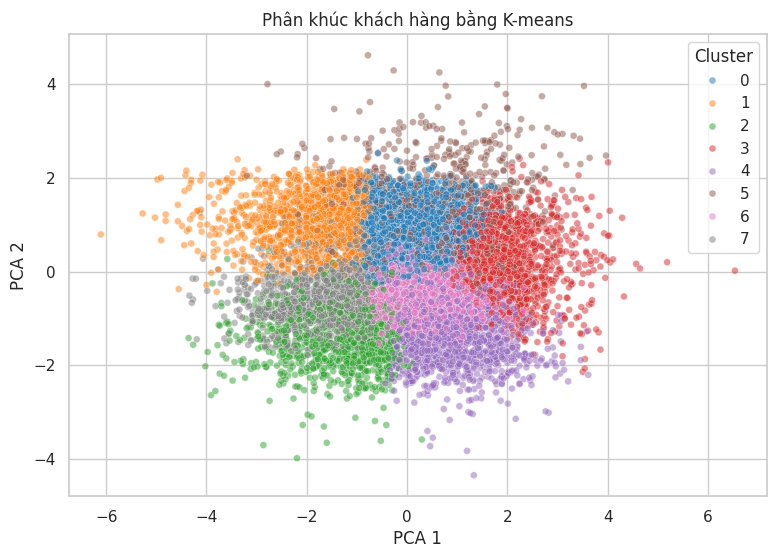

In [14]:
plot_size = min(10_000, len(X_cluster))
plot_indices = np.random.choice(len(X_cluster), size=plot_size, replace=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_plot = pca.fit_transform(X_cluster[plot_indices])
plot_clusters = train_data["CLUSTER"].to_numpy()[plot_indices]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_plot[:, 0],
    y=X_plot[:, 1],
    hue=plot_clusters,
    palette="tab10",
    alpha=0.5,
    s=25,
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Phân khúc khách hàng bằng K-means")
plt.legend(title="Cluster")
plt.show()

In [15]:
cluster_profile = (
    train_data.groupby("CLUSTER")
    .agg(
        CUSTOMERS=("SK_ID_CURR", "size"),
        DEFAULT_RATE=("TARGET", "mean"),
        INCOME=("AMT_INCOME_TOTAL", "median"),
        CREDIT=("AMT_CREDIT", "median"),
        ANNUITY=("AMT_ANNUITY", "median"),
        AGE=("AGE_YEARS", "median"),
        EMPLOYED_YEARS=("EMPLOYED_YEARS", "median"),
        FAMILY_SIZE=("CNT_FAM_MEMBERS", "median"),
        MOST_COMMON_CONTRACT=("NAME_CONTRACT_TYPE", lambda x: x.mode().iat[0]),
    )
)

cluster_profile["PERCENT_OF_CUSTOMERS"] = (
    100 * cluster_profile["CUSTOMERS"] / len(train_data)
)
cluster_profile["DEFAULT_RATE_PERCENT"] = 100 * cluster_profile["DEFAULT_RATE"]

display(cluster_profile.round(2))

,CUSTOMERS,DEFAULT_RATE,INCOME,CREDIT,ANNUITY,AGE,EMPLOYED_YEARS,FAMILY_SIZE,MOST_COMMON_CONTRACT,PERCENT_OF_CUSTOMERS,DEFAULT_RATE_PERCENT
CLUSTER,,,,,,,,,,,
0,59008,0.07,135000.0,605439.0,26145.0,55.81,4.53,2.0,Cash loans,19.19,7.07
1,36384,0.05,90000.0,226665.0,13189.5,58.38,5.12,2.0,Cash loans,11.83,5.47
2,28570,0.09,112500.0,252954.0,14382.0,34.79,3.84,3.0,Cash loans,9.29,8.97
3,40512,0.06,270000.0,1097676.0,44694.0,46.88,5.77,2.0,Cash loans,13.17,5.87
4,42769,0.09,180000.0,685012.5,31630.5,36.25,4.33,3.0,Cash loans,13.91,9.48
5,21810,0.05,157500.0,578979.0,26145.0,49.31,20.88,2.0,Cash loans,7.09,4.63
6,45400,0.12,157500.0,545040.0,28408.5,32.54,3.16,2.0,Cash loans,14.76,11.59
7,33058,0.10,119250.0,225000.0,13500.0,32.18,2.97,2.0,Cash loans,10.75,10.27


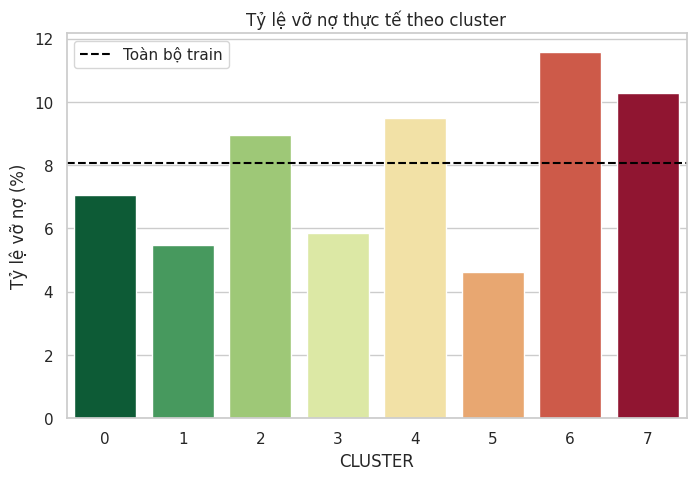

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_profile.reset_index(),
    x="CLUSTER",
    y="DEFAULT_RATE_PERCENT",
    hue="CLUSTER",
    palette="RdYlGn_r",
    legend=False,
)
plt.axhline(100 * train_data["TARGET"].mean(), color="black", linestyle="--", label="Toàn bộ train")
plt.ylabel("Tỷ lệ vỡ nợ (%)")
plt.title("Tỷ lệ vỡ nợ thực tế theo cluster")
plt.legend()
plt.show()

### Cách viết nhận xét kinh doanh

Không nên gán trước ý nghĩa cho số cluster vì K-means có thể đổi thứ tự nhãn giữa các lần thiết lập khác nhau. Sau khi chạy bảng `cluster_profile`, hãy mô tả theo số liệu thực tế:

- Cluster có thu nhập và số năm làm việc cao, default rate thấp: nhóm tài chính ổn định, có thể ưu tiên sản phẩm tốt hơn.
- Cluster trẻ, thời gian làm việc ngắn và default rate cao: nhóm cần thẩm định kỹ hoặc hạn mức thận trọng.
- Cluster có khoản vay/tiền trả hàng năm cao: nhóm dư nợ lớn, cần theo dõi khả năng trả nợ dù thu nhập có thể cao.
- Cluster chủ yếu là revolving loan: có hành vi vay khác cash loan và nên có chính sách riêng.

Nếu các cột default rate gần nhau, kết luận rằng phân khúc hành vi/tài chính **chưa tách rõ rủi ro tín dụng**. Nếu chênh lệch lớn, cluster đã nhận diện được nhóm rủi ro tương đối cao/thấp. Cluster là phân khúc mô tả, không tự động mang quan hệ nhân quả.

## 5. Logistic Regression có và không có feature cluster

Ngoài các feature dùng để phân cụm, model phân loại dùng thêm giới tính, loại thu nhập, học vấn, tình trạng gia đình, nhà ở và ba `EXT_SOURCE`. Ba điểm external source thường hữu ích cho dự đoán rủi ro, nhưng không được dùng để định nghĩa chân dung cluster.

Để so sánh AUC công bằng, ta chia train/validation trước. Preprocessing và K-means ở phần đánh giá chỉ fit trên 80% training split, sau đó mới dự đoán cluster cho validation.

In [17]:
MODEL_NUMERIC_FEATURES = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "AGE_YEARS", "EMPLOYED_YEARS", "CNT_FAM_MEMBERS",
    "REGION_POPULATION_RELATIVE", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]
MODEL_CATEGORICAL_FEATURES = [
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
]
MODEL_FEATURES = MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES

train_part, valid_part = train_test_split(
    train_data,
    test_size=0.20,
    stratify=train_data["TARGET"],
    random_state=RANDOM_STATE,
)

print("Train split     :", train_part.shape)
print("Validation split:", valid_part.shape)

Train split     : (246008, 128)
Validation split: (61503, 128)


In [18]:
def make_classification_pipeline(categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, MODEL_NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, categorical_features),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])

### 5.1. Model cơ sở không có cluster

In [19]:
baseline_model = make_classification_pipeline(MODEL_CATEGORICAL_FEATURES)
baseline_model.fit(train_part[MODEL_FEATURES], train_part["TARGET"])

baseline_probability = baseline_model.predict_proba(valid_part[MODEL_FEATURES])[:, 1]
baseline_auc = roc_auc_score(valid_part["TARGET"], baseline_probability)

print(f"Validation AUC không có cluster: {baseline_auc:.5f}")

Validation AUC không có cluster: 0.73927


### 5.2. Model có thêm cluster

Nhãn cluster là category, không phải đại lượng có thứ tự. Vì vậy ta đổi nhãn thành chuỗi và để `OneHotEncoder` xử lý.

In [20]:
evaluation_cluster_preprocessor = make_cluster_preprocessor()
X_cluster_train = evaluation_cluster_preprocessor.fit_transform(train_part[CLUSTER_FEATURES])
X_cluster_valid = evaluation_cluster_preprocessor.transform(valid_part[CLUSTER_FEATURES])

evaluation_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
)

train_part = train_part.copy()
valid_part = valid_part.copy()
train_part["CLUSTER"] = evaluation_kmeans.fit_predict(X_cluster_train).astype(str)
valid_part["CLUSTER"] = evaluation_kmeans.predict(X_cluster_valid).astype(str)

cluster_model_features = MODEL_FEATURES + ["CLUSTER"]
cluster_categorical_features = MODEL_CATEGORICAL_FEATURES + ["CLUSTER"]

cluster_model = make_classification_pipeline(cluster_categorical_features)
cluster_model.fit(train_part[cluster_model_features], train_part["TARGET"])

cluster_probability = cluster_model.predict_proba(valid_part[cluster_model_features])[:, 1]
cluster_auc = roc_auc_score(valid_part["TARGET"], cluster_probability)

print(f"Validation AUC không có cluster: {baseline_auc:.5f}")
print(f"Validation AUC có cluster      : {cluster_auc:.5f}")
print(f"Chênh lệch AUC                 : {cluster_auc - baseline_auc:+.5f}")

Validation AUC không có cluster: 0.73927
Validation AUC có cluster      : 0.74043
Chênh lệch AUC                 : +0.00116


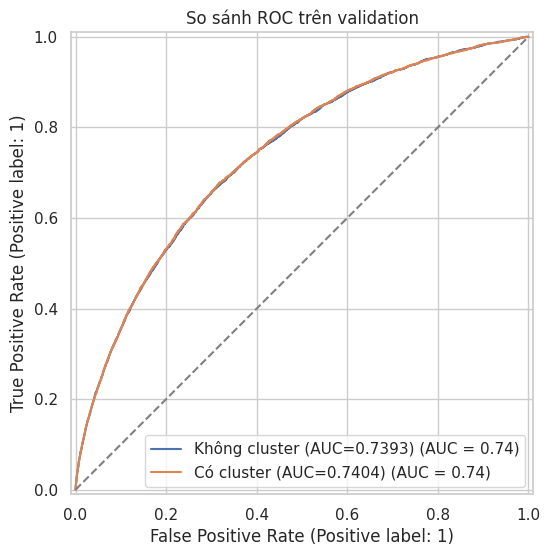

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    valid_part["TARGET"], baseline_probability,
    name=f"Không cluster (AUC={baseline_auc:.4f})", ax=ax,
)
RocCurveDisplay.from_predictions(
    valid_part["TARGET"], cluster_probability,
    name=f"Có cluster (AUC={cluster_auc:.4f})", ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("So sánh ROC trên validation")
plt.show()

AUC càng gần 1 càng tốt; 0.5 tương đương xếp hạng ngẫu nhiên. Nếu AUC có cluster chỉ tăng rất ít hoặc giảm, điều đó vẫn hợp lý: K-means tối ưu khoảng cách giữa hồ sơ khách hàng, không trực tiếp tối ưu `TARGET`.

## 6. Fit toàn bộ train và tạo file nộp Kaggle

Sau khi đã đánh giá, ta fit lại preprocessing, K-means và Logistic Regression trên toàn bộ train. Test chỉ được transform/predict bằng các đối tượng đã học từ train.

In [22]:
final_cluster_preprocessor = make_cluster_preprocessor()
X_cluster_full_train = final_cluster_preprocessor.fit_transform(train_data[CLUSTER_FEATURES])
X_cluster_test = final_cluster_preprocessor.transform(test_data[CLUSTER_FEATURES])

final_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
)

train_data["CLUSTER"] = final_kmeans.fit_predict(X_cluster_full_train).astype(str)
test_data["CLUSTER"] = final_kmeans.predict(X_cluster_test).astype(str)

final_model = make_classification_pipeline(cluster_categorical_features)
final_model.fit(train_data[cluster_model_features], train_data["TARGET"])
test_probability = final_model.predict_proba(test_data[cluster_model_features])[:, 1]

In [23]:
submission = pd.DataFrame({
    "SK_ID_CURR": test_data["SK_ID_CURR"],
    "TARGET": test_probability,
})

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
print("TARGET min/max :", submission["TARGET"].min(), submission["TARGET"].max())
display(submission.head())

Submission shape: (48744, 2)
TARGET min/max : 0.0374525435820038 0.9685507519998193


,SK_ID_CURR,TARGET
0,100001,0.381416
1,100005,0.571410
2,100013,0.251640
3,100028,0.281428
4,100038,0.627838


In [24]:
# Tự tải file về máy khi chạy trên Google Colab
try:
    from google.colab import files
    files.download("submission.csv")
except ImportError:
    print("Đã lưu submission.csv trong thư mục notebook.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Ghi nhận kết quả Kaggle

Sau khi nộp `submission.csv` vào competition **Home Credit Default Risk**, điền kết quả thật vào bảng sau:

| Model | Validation AUC | Kaggle Public AUC |
|---|---:|---:|
| Logistic Regression + cluster | *(kết quả cell trên)* | *(điền sau khi submit)* |

Điểm leaderboard không thể biết trước từ notebook; chỉ ghi điểm Kaggle hiển thị sau khi submission được chấm.

## 8. Kết luận gợi ý

K-means giúp tạo các phân khúc khách hàng dễ mô tả dựa trên quy mô khoản vay, thu nhập, tuổi, độ ổn định việc làm và loại hợp đồng. So sánh `DEFAULT_RATE` cho biết các phân khúc đó có đồng thời tách biệt rủi ro hay không. Tuy nhiên, feature cluster có thể không làm Logistic Regression tốt hơn đáng kể vì nó là bản tóm tắt thô của những feature model đã nhìn thấy. Kết luận cuối cùng cần dựa trên bảng profile và hai AUC thực tế sau khi chạy notebook.